In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from scipy.optimize import curve_fit
import os
model_checkpoint = "Qwen/Qwen3.5-2B"
#model_checkpoint = "Qwen/Qwen3.5-4B"
#model_checkpoint = "google/gemma-4-E2B"
#model_checkpoint = "Qwen/Qwen3.5-0.8B"
#model_checkpoint = "meta-llama/Llama-3.2-3B"
model_checkpoint_str = model_checkpoint.split("/")[-1]
MULT_CACHE_DIR = f"./mult_baseline/{model_checkpoint_str}"
model_answers_arr = np.load(os.path.join(MULT_CACHE_DIR, "model_answers.npy"))
ground_truths_arr = np.load(os.path.join(MULT_CACHE_DIR, "ground_truths.npy"))
categories_arr    = np.load(os.path.join(MULT_CACHE_DIR, "categories.npy"))
correct_arr       = np.load(os.path.join(MULT_CACHE_DIR, "correct.npy"))
operand_pairs_arr = np.load(os.path.join(MULT_CACHE_DIR, "operand_pairs.npy"))

Max value across all examples: 99
Max value across all examples: 99
Max value across all examples: 99

--- 2×2 ---
  Total (Φ, digit) pairs: 24,300
  Overall digit error rate: 0.160
  Φ range: [0.00, 17.01]
  Q-function fit: σ=0.127, R²=-1.744


/var/folders/fk/jts3h3f94s3dgx9cn2rnlz7c0000gn/T/ipykernel_36420/1326063468.py:128: RuntimeWarning: invalid value encountered in divide
  correct_pct   = np.where(n_total > 0, 100.0 * n_correct   / n_total, 0)
/var/folders/fk/jts3h3f94s3dgx9cn2rnlz7c0000gn/T/ipykernel_36420/1326063468.py:129: RuntimeWarning: invalid value encountered in divide
  incorrect_pct = np.where(n_total > 0, 100.0 * n_incorrect / n_total, 0)


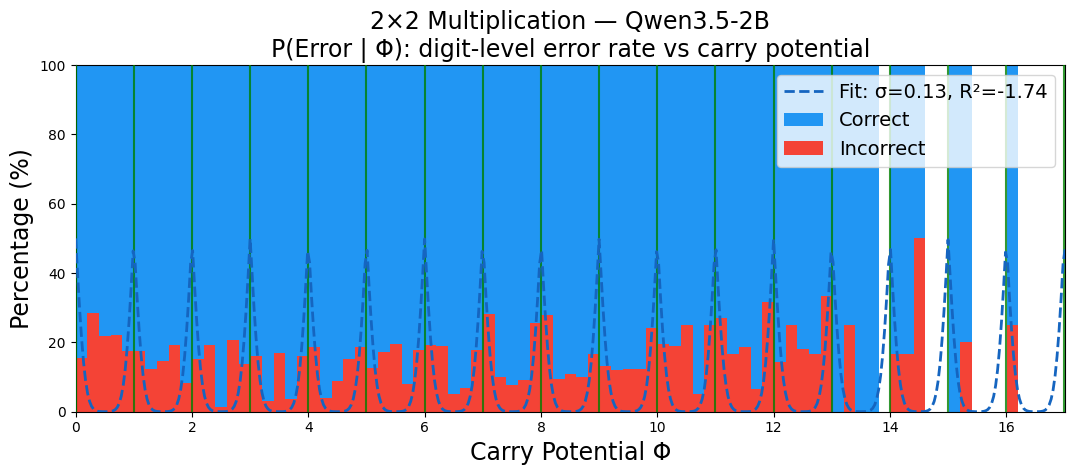

Error rate near boundary:      0.150
Error rate far from boundary:  0.166
Ratio (near/far):              0.90
Overall digit error rate:       0.160
Baseline error rate (far):      0.166
Near-boundary error rate:       0.150
Excess near boundary:           -0.017
Fraction explained by carry noise:        -4.0%
Fraction explained by partial product err:104.0%
Max value across all examples: 999
Max value across all examples: 999
Max value across all examples: 999
Max value across all examples: 999

--- 2×3 ---
  Total (Φ, digit) pairs: 12,000
  Overall digit error rate: 0.136
  Φ range: [0.00, 17.01]
  Q-function fit: σ=0.284, R²=-0.906


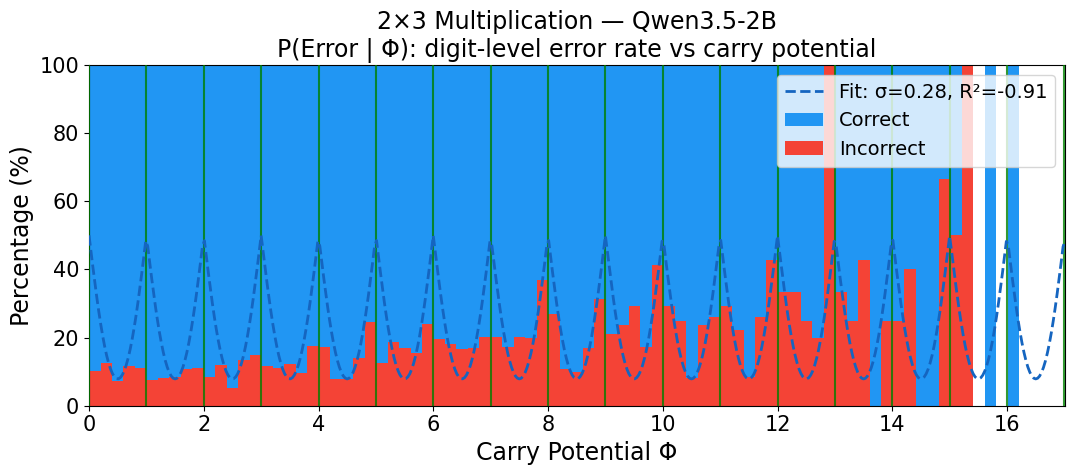

Error rate near boundary:      0.148
Error rate far from boundary:  0.129
Ratio (near/far):              1.15
Overall digit error rate:       0.136
Baseline error rate (far):      0.129
Near-boundary error rate:       0.148
Excess near boundary:           0.019
Fraction explained by carry noise:        5.3%
Fraction explained by partial product err:94.7%
Max value across all examples: 999
Max value across all examples: 999
Max value across all examples: 999
Max value across all examples: 999
Max value across all examples: 999

--- 3×3 ---
  Total (Φ, digit) pairs: 15,000
  Overall digit error rate: 0.239
  Φ range: [0.00, 22.06]
  Q-function fit: σ=0.526, R²=0.014


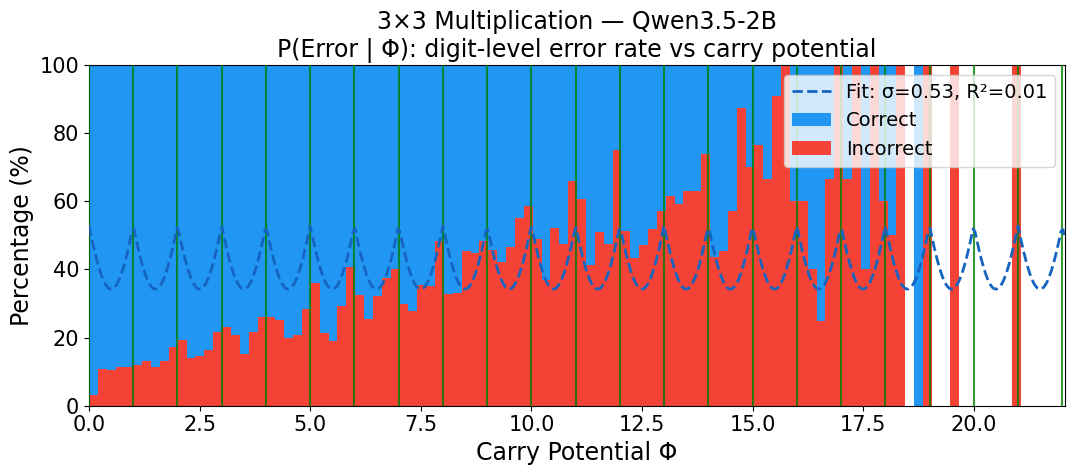

Error rate near boundary:      0.269
Error rate far from boundary:  0.219
Ratio (near/far):              1.22
Overall digit error rate:       0.239
Baseline error rate (far):      0.219
Near-boundary error rate:       0.269
Excess near boundary:           0.049
Fraction explained by carry noise:        8.1%
Fraction explained by partial product err:91.9%
Max value across all examples: 9995
Max value across all examples: 9995
Max value across all examples: 9995
Max value across all examples: 9995
Max value across all examples: 9995

--- 2x4 ---
  Total (Φ, digit) pairs: 5,000
  Overall digit error rate: 0.098
  Φ range: [0.00, 17.89]
  Q-function fit: σ=0.156, R²=-0.194


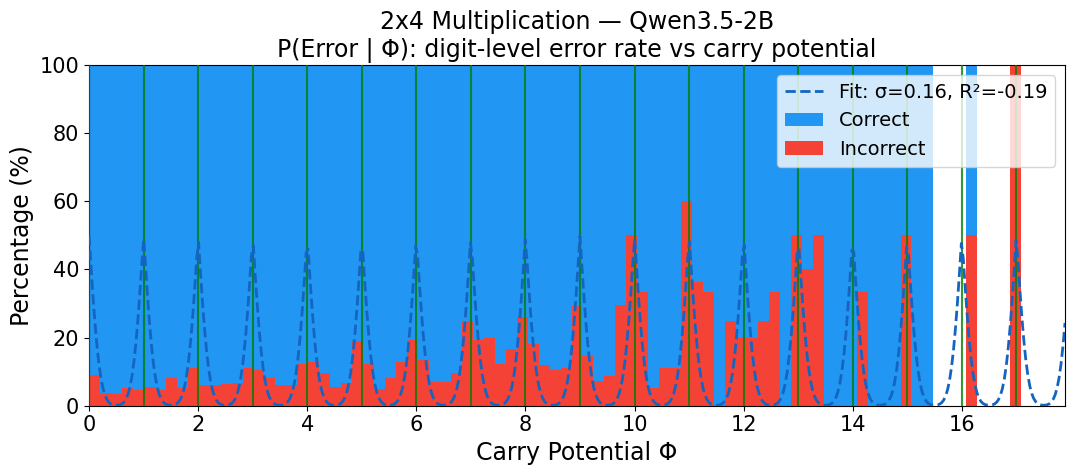

Error rate near boundary:      0.133
Error rate far from boundary:  0.076
Ratio (near/far):              1.74
Overall digit error rate:       0.098
Baseline error rate (far):      0.076
Near-boundary error rate:       0.133
Excess near boundary:           0.056
Fraction explained by carry noise:        22.4%
Fraction explained by partial product err:77.6%
Max value across all examples: 9996
Max value across all examples: 9996
Max value across all examples: 9996
Max value across all examples: 9996
Max value across all examples: 9996
Max value across all examples: 9996

--- 3x4 ---
  Total (Φ, digit) pairs: 6,000
  Overall digit error rate: 0.292
  Φ range: [0.00, 19.51]
  Q-function fit: σ=0.542, R²=0.049


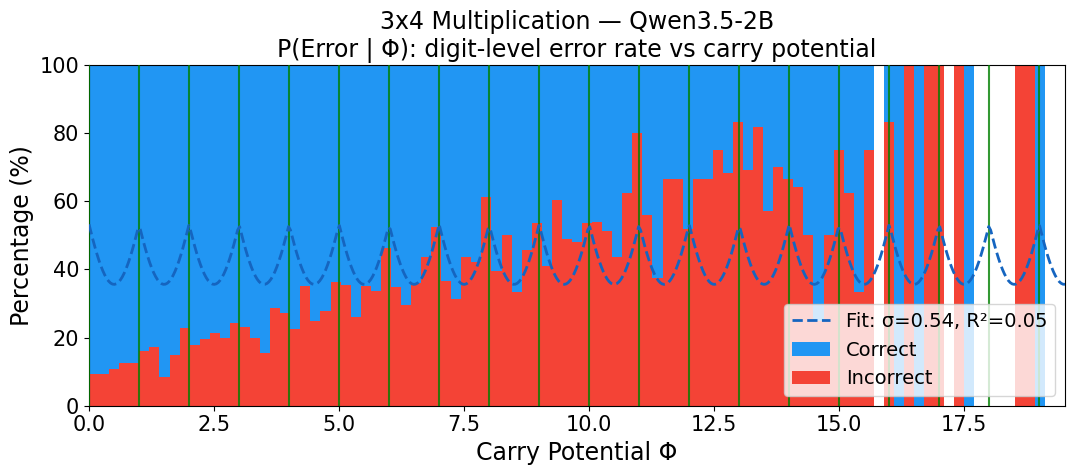

Error rate near boundary:      0.323
Error rate far from boundary:  0.272
Ratio (near/far):              1.19
Overall digit error rate:       0.292
Baseline error rate (far):      0.272
Near-boundary error rate:       0.323
Excess near boundary:           0.051
Fraction explained by carry noise:        6.8%
Fraction explained by partial product err:93.2%


In [6]:
from scipy.optimize import curve_fit
from scipy.special import erfc

def get_column_carry_potentials(a_arr, b_arr, target_column):
    """
    Calculates the continuous carry potential (Phi) flowing into a specific column.
    
    Args:
        a_arr (np.ndarray): 1D array of first operands.
        b_arr (np.ndarray): 1D array of second operands.
        target_column (int): The column receiving the carry (0=units, 1=tens, 2=hundreds).
        
    Returns:
        phi_array (np.ndarray): 1D array of continuous carry potentials for all examples.
    """
    # 1. Determine the maximum number of digits across all examples
    max_val = max(np.max(a_arr), np.max(b_arr))
    print(f"Max value across all examples: {max_val}")
    max_digits = len(str(max_val))
    
    # 2. Extract base-10 digits for all examples
    a_digits = np.array([(a_arr // (10**i)) % 10 for i in range(max_digits)])
    b_digits = np.array([(b_arr // (10**i)) % 10 for i in range(max_digits)])
    
    phi_array = np.zeros(len(a_arr))
    
    # 3. Accumulate momentum only from columns to the right of the target
    for p in range(target_column): 
        S_p = np.zeros(len(a_arr))
        
        # Compute the raw sum for column p
        for i in range(p + 1):
            k = p - i
            if i < max_digits and k < max_digits:
                S_p += a_digits[i] * b_digits[k]
        
        # Calculate how far this column is from the target column
        distance = target_column - p
        
        # Add the fractional momentum to the total potential
        phi_array += S_p / (10 ** distance)
        
    return phi_array


def q_function_phi(phi, sigma):
    """
    P(Error | Φ) from Paper 1 Equation 6.
    Takes raw Φ (not δ), computes δ = Φ mod 1 internally.
    This produces the repeating bathtub shape across the full Φ range.
    Q(x) = erfc(x / sqrt(2)) / 2
    """
    delta = phi % 1.0
    return (erfc(delta / (np.sqrt(2) * sigma)) / 2 +
            erfc((1 - delta) / (np.sqrt(2) * sigma)) / 2)


for col_name, mask_all in [
    ("2×2", mask_2x2_all),
    ("2×3", mask_2x3_all),
    ("3×3", mask_3x3_all),
    ("2x4", mask_2x4_all),
    ("3x4", mask_3x4_all),
]:
    a_all    = operand_pairs_arr[mask_all, 0]
    b_all    = operand_pairs_arr[mask_all, 1]
    gt_all   = ground_truths_arr[mask_all]
    pred_all = model_answers_arr[mask_all]

    max_product      = int(np.max(gt_all))
    n_output_columns = len(str(max_product))

    phi_all     = []   # all Φ values
    errors_all  = []   # 1 = digit wrong, 0 = digit correct

    for k in range(1, n_output_columns):
        phi_k = get_column_carry_potentials(a_all, b_all, target_column=k)

        gt_digit_k   = (gt_all   // (10**k)) % 10
        safe_pred    = np.where(pred_all < 0, -999, pred_all)
        pred_digit_k = (safe_pred // (10**k)) % 10
        is_correct_k = (gt_digit_k == pred_digit_k) & (pred_all >= 0)

        phi_all.extend(phi_k.tolist())
        errors_all.extend((~is_correct_k).astype(float).tolist())

    phi_all    = np.array(phi_all)
    errors_all = np.array(errors_all)

    print(f"\n--- {col_name} ---")
    print(f"  Total (Φ, digit) pairs: {len(phi_all):,}")
    print(f"  Overall digit error rate: {errors_all.mean():.3f}")
    print(f"  Φ range: [{phi_all.min():.2f}, {phi_all.max():.2f}]")

    # ── Bin by raw Φ ─────────────────────────────────────────────────────────
    # Use enough bins to show the repeating pattern clearly
    condition = phi_all < 40.0
    phi_all = phi_all[condition]
    errors_all = errors_all[condition]
    phi_max = phi_all.max()
    n_bins  = max(40, int(phi_max * 5))   # ~15 bins per integer interval
    bins    = np.linspace(0, phi_max, n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # For each bin: count correct and incorrect
    n_correct   = []
    n_incorrect = []
    error_pct   = []

    for i in range(n_bins):
        in_bin    = (phi_all >= bins[i]) & (phi_all < bins[i+1])
        n_tot     = in_bin.sum()
        n_err     = errors_all[in_bin].sum()
        n_ok      = n_tot - n_err
        n_correct.append(n_ok)
        n_incorrect.append(n_err)
        if n_tot >= 5:
            error_pct.append(100.0 * n_err / n_tot)
        else:
            error_pct.append(np.nan)

    n_correct   = np.array(n_correct,   dtype=float)
    n_incorrect = np.array(n_incorrect, dtype=float)
    error_pct   = np.array(error_pct)
    n_total     = n_correct + n_incorrect

    # Convert to percentage of total in each bin
    correct_pct   = np.where(n_total > 0, 100.0 * n_correct   / n_total, 0)
    incorrect_pct = np.where(n_total > 0, 100.0 * n_incorrect / n_total, 0)

    # ── Fit Q-function using δ(Φ) across all valid bins ──────────────────────
    valid = ~np.isnan(error_pct) & (n_total >= 5)
    sigma_fit, r2 = None, None

    if valid.sum() >= 5:
        try:
            popt, _ = curve_fit(
                lambda phi, sigma: q_function_phi(phi, sigma) * 100,
                bin_centers[valid],
                error_pct[valid],
                p0=[0.1],
                bounds=(0.001, 2.0)
            )
            sigma_fit = popt[0]
            pred_pct  = q_function_phi(bin_centers[valid], sigma_fit) * 100
            ss_res    = np.sum((error_pct[valid] - pred_pct)**2)
            ss_tot    = np.sum((error_pct[valid] - error_pct[valid].mean())**2)
            r2        = 1 - ss_res / (ss_tot + 1e-8)
            print(f"  Q-function fit: σ={sigma_fit:.3f}, R²={r2:.3f}")
        except Exception as e:
            print(f"  Q-fit failed: {e}")

    # ── Plot: Figure 5 bottom panel ───────────────────────────────────────────
    bar_width = bins[1] - bins[0]

    fig, ax = plt.subplots(figsize=(11, 5))
    plt.rcParams.update({'font.size': 15})
    # Stacked bars: blue (correct %) bottom, red (incorrect %) on top
    ax.bar(bin_centers, correct_pct,   width=bar_width, color="#2196F3",
           bottom=incorrect_pct, label="Correct",   align="center", zorder=2)
    ax.bar(bin_centers, incorrect_pct, width=bar_width, color="#F44336",
           bottom=0, label="Incorrect", align="center", zorder=2)

    # Q-function fit curve
    if sigma_fit is not None:
        phi_smooth  = np.linspace(0, phi_max, 500)
        fit_smooth  = q_function_phi(phi_smooth, sigma_fit) * 100
        ax.plot(phi_smooth, fit_smooth, color="#1565C0", linewidth=2,
                linestyle="--", zorder=4,
                label=f"Fit: σ={sigma_fit:.2f}, R²={r2:.2f}")

    # Integer boundary lines (green)
    for iv in range(0, int(phi_max) + 2):
        ax.axvline(iv, color="green", linestyle="-",
                   linewidth=1.5, alpha=0.8, zorder=3)

    ax.set_xlim(0, phi_max)
    ax.set_ylim(0, 100)
    ax.set_xlabel("Carry Potential Φ", fontsize=17)
    ax.set_ylabel("Percentage (%)", fontsize=17)
    ax.set_title(
        f"{col_name} Multiplication — {model_checkpoint_str}\n"
        f"P(Error | Φ): digit-level error rate vs carry potential",
        fontsize=17
    )
    ax.legend(fontsize=14)
    plt.tight_layout()
    plt.savefig(
        os.path.join(MULT_CACHE_DIR,
                     f"fig5_bottom_{col_name.replace('×','x')}.png"),
        dpi=150
    )
    plt.show()
    # For each bin, what fraction of errors occur near boundaries vs far from them?
    # Define "near boundary" as delta(Phi) < 0.2 or > 0.8
    delta_phi = phi_all % 1.0
    near_boundary = (delta_phi < 0.2) | (delta_phi > 0.8)
    far_from_boundary = ~near_boundary

    print(f"Error rate near boundary:      {errors_all[near_boundary].mean():.3f}")
    print(f"Error rate far from boundary:  {errors_all[far_from_boundary].mean():.3f}")
    print(f"Ratio (near/far):              {errors_all[near_boundary].mean() / errors_all[far_from_boundary].mean():.2f}")
    # Baseline error rate (far from boundary — mostly mechanism 2)
    baseline = errors_all[far_from_boundary].mean()

    # Excess error near boundary (mechanism 1 on top of baseline)
    near_rate = errors_all[near_boundary].mean()
    excess = near_rate - baseline

    # What fraction of total errors does each mechanism explain?
    total_error_rate = errors_all.mean()
    frac_mechanism1 = excess * near_boundary.mean() / total_error_rate
    frac_mechanism2 = 1 - frac_mechanism1

    print(f"Overall digit error rate:       {total_error_rate:.3f}")
    print(f"Baseline error rate (far):      {baseline:.3f}")
    print(f"Near-boundary error rate:       {near_rate:.3f}")
    print(f"Excess near boundary:           {excess:.3f}")
    print(f"Fraction explained by carry noise:        {frac_mechanism1:.1%}")
    print(f"Fraction explained by partial product err:{frac_mechanism2:.1%}")

Example: 99*55 = 5445, carry columns: 3
No carry:   660
Low carry:  5136
High carry: 11195
[(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 1), (2, 2), (2, 3), (2, 4), (3, 1), (3, 2), (3, 3), (4, 1), (4, 2), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (1, 18), (1, 19), (1, 20), (1, 21), (1, 22), (1, 23), (1, 24), (1, 25), (1, 26), (1, 27), (1, 28), (1, 29), (1, 30), (1, 31), (1, 32), (1, 33), (1, 34), (1, 35), (1, 36), (1, 37), (1, 38), (1, 39), (1, 40), (1, 41), (1, 42), (1, 43), (1, 44), (1, 45), (1, 46), (1, 47), (1, 48), (1, 49), (1, 50), (1, 51), (1, 52), (1, 53), (1, 54), (1, 55), (1, 56), (1, 57), (1, 58), (1, 59), (1, 60), (1, 61), (1, 62), (1, 63), (1, 64), (1, 65), (1, 66), (1, 67), (1, 68), (1, 69), (1, 70), (1, 71), (1, 72), (1, 73), (1, 74), (1, 75), (1, 76), (1, 77), (1, 78), (1, 79), (1, 80), (1, 81), (1, 82), (1, 83), (1, 84), (1, 85), (1, 86), (1, 87), (1, 88), (1, 89), (1, 

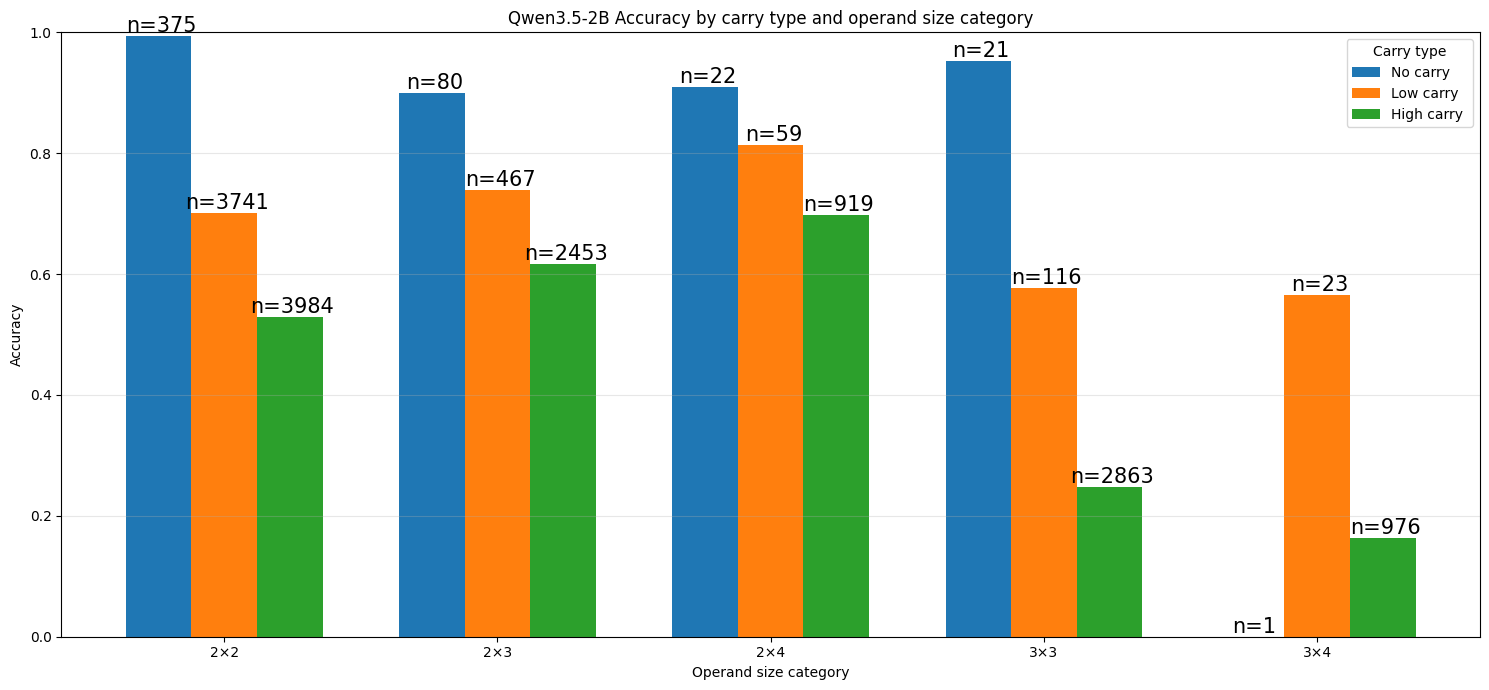

In [4]:
def requires_carry_at_column(a, b, column):
    """
    Returns True if computing the product a*b requires a carry
    into the given output column.
    A carry is needed at column k if the partial product sum
    at columns 0..k-1 exceeds 10^k.
    """
    n_dig_a = len(str(a))
    n_dig_b = len(str(b))
    a_digits = [(a // 10**i) % 10 for i in range(n_dig_a)]
    b_digits = [(b // 10**i) % 10 for i in range(n_dig_b)]

    # Partial product sum at each column below k
    V_below_k = 0
    for j in range(column):
        p_j = sum(a_digits[i] * b_digits[j-i]
                  for i in range(min(j+1, n_dig_a))
                  if (j-i) < n_dig_b)
        V_below_k += p_j * (10**j)

    return (V_below_k // (10**column)) > 0  # True if there is a carry

def count_carry_columns(a, b):
    """Count how many output columns require a carry."""
    n_out = len(str(a*b))
    return sum(1 for k in range(1, n_out)
               if requires_carry_at_column(a, b, k))
print(f"Example: 99*55 = {99*55}, carry columns: {count_carry_columns(99, 55)}")
# Build stratified dataset
import itertools
no_carry_pairs  = []
low_carry_pairs = []   # 1-2 carry columns
high_carry_pairs= []   # 3+ carry columns

#for a, b in itertools.product(range(10, 100), range(10, 100)):
for a, b in operand_pairs_arr:
    n_carries = count_carry_columns(a, b)
    if n_carries == 0:
        no_carry_pairs.append((a, b))
    elif n_carries <= 2:
        low_carry_pairs.append((a, b))
    else:
        high_carry_pairs.append((a, b))

print(f"No carry:   {len(no_carry_pairs)}")
print(f"Low carry:  {len(low_carry_pairs)}")
print(f"High carry: {len(high_carry_pairs)}")
print(no_carry_pairs)
print(operand_pairs_arr.shape)

no_carry_pairs  = np.array(no_carry_pairs)
low_carry_pairs = np.array(low_carry_pairs)
high_carry_pairs= np.array(high_carry_pairs)
mask_2x2_all   = categories_arr == "2x2"
mask_3x3_all   = categories_arr == "3x3"
mask_2x3_all   = categories_arr == "2x3"
mask_2x4_all   = categories_arr == "2x4"
mask_3x4_all   = categories_arr == "3x4"
carry_category_masks = [
    ("2×2", mask_2x2_all),
    ("2×3", mask_2x3_all),
    ("2×4", mask_2x4_all),
    ("3×3", mask_3x3_all),
    ("3×4", mask_3x4_all),
]
# Compute carry count directly for each pair in operand_pairs_arr
carry_counts = np.array([count_carry_columns(a, b) for a, b in operand_pairs_arr])

# Create mutually exclusive boolean masks
mask_no_carry   = (carry_counts == 0)
mask_low_carry  = (carry_counts >= 1) & (carry_counts <= 2)
mask_high_carry = (carry_counts >= 3)
# mask_no_carry = np.isin(operand_pairs_arr, no_carry_pairs).all(axis=1)
# mask_low_carry = np.isin(operand_pairs_arr, low_carry_pairs).all(axis=1)
# mask_high_carry = np.isin(operand_pairs_arr, high_carry_pairs).all(axis=1)

category_labels = []
category_accs = []
category_counts = []

for col_name, mask_all in carry_category_masks:
    mask_no = mask_all & mask_no_carry
    mask_low = mask_all & mask_low_carry
    mask_high = mask_all & mask_high_carry

    no_carry_accuracy = correct_arr[mask_no].mean() if mask_no.sum() else np.nan
    low_carry_accuracy = correct_arr[mask_low].mean() if mask_low.sum() else np.nan
    high_carry_accuracy = correct_arr[mask_high].mean() if mask_high.sum() else np.nan

    category_labels.append(col_name)
    category_accs.append([no_carry_accuracy, low_carry_accuracy, high_carry_accuracy])
    category_counts.append([mask_no.sum(), mask_low.sum(), mask_high.sum()])

    print(f"\nError magnitude breakdown for {col_name} multiplication:")
    errors_magnitude = np.abs(model_answers_arr[mask_all] - ground_truths_arr[mask_all])
    print(f" Number divisible by 10: {(errors_magnitude % 10 == 0).sum() / len(errors_magnitude):.4f}")
    print(f"Accuracy for {col_name} multiplication:")
    print(f"  No carry:   {no_carry_accuracy:.3f}    Num examples: {mask_no.sum()}")
    print(f"  Low carry:  {low_carry_accuracy:.3f}    Num examples: {mask_low.sum()}")
    print(f"  High carry: {high_carry_accuracy:.3f}    Num examples: {mask_high.sum()}")

category_accs = np.array(category_accs)
category_counts = np.array(category_counts)
fig2, ax2 = plt.subplots(figsize=(15, 7))
x = np.arange(len(category_labels))
width = 0.24

carry_types = ["No carry", "Low carry", "High carry"]
for i, carry_type in enumerate(carry_types):
    bars = ax2.bar(x + (i - 1) * width, category_accs[:, i], width, label=f"{carry_type} ")

    print(f"Category {category_labels[i]} - {carry_type}: {category_counts[:, i]}")
    #ax2.bar_label(bars,labels=f"{category_accs[:, i].shape[0]}", padding=3)

for i in range(len(category_labels)):
    for j in range(len(carry_types)):
        acc = category_accs[i, j]
        if not np.isnan(acc):
            ax2.text(x[i] + (j - 1) * width+0.01, acc, f"n={category_counts[i, j]}",
                     ha="center", va="bottom", fontsize=15)

ax2.set_xticks(x)
ax2.set_xticklabels(category_labels)
ax2.set_ylim(0, 1)
ax2.set_ylabel("Accuracy")
ax2.set_xlabel("Operand size category")
ax2.set_title("Qwen3.5-2B Accuracy by carry type and operand size category")
ax2.legend(title="Carry type")
ax2.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(MULT_CACHE_DIR, "carry_type_accuracy.png"), dpi=150)
plt.show()



